<a href="https://colab.research.google.com/github/alextyner-tailwater/Tailwater/blob/main/Tutorials/Port_To_PyBinding_PythTB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Load Packages
!pip install tailwater
!pip install pybinding-dev
!pip install seekpath
!pip install mp_api
!pip install pythtb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.0/336.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 80.7 MB/s eta 0:00:00
   ━━━

In [1]:
#Define API Keys:
#Materials Project API Key
API_KEY = #Your Materials Project API Key
#Tailwater User + Password
TW_USER= # Your Tailwater Username
TW_PASS= #Your Tailwater Password

In [2]:
import os
from mp_api.client import MPRester
mp_id='mp-104' #Materials Project ID for KTaO3
with MPRester(API_KEY) as mpr:
    print(f"Querying the Materials Project for {mp_id}...")


    # 1. Fetch summary data (Structure and Band Gap)
    # Passing the ID in a list to material_ids isolates the specific material
    summary_docs = mpr.materials.summary.search(
        material_ids=[mp_id],
        fields=["material_id", "structure", "band_gap","dos"]
    )

    if not summary_docs:
        print(f"Could not find summary data for {mp_id}. Check the ID.")
        #return

    doc = summary_docs[0]
    band_gap = doc.band_gap
    structure = doc.structure
structure

Querying the Materials Project for mp-104...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Structure Summary
Lattice
    abc : 4.581209043685215 4.581210190248658 4.581208787331966
 angles : 56.7469248798343 56.74692392237344 56.746918415943504
 volume : 62.881010949113254
      A : 3.83577146 0.0059445900000000005 2.50485494
      B : 1.35894867 3.58698298 2.5048549700000002
      C : 0.0085938 0.0059445800000000005 4.58119687
    pbc : True True True
PeriodicSite: Sb (1.396, 0.9654, 2.573) [0.2683, 0.2683, 0.2683]
PeriodicSite: Sb (3.807, 2.633, 7.018) [0.7317, 0.7317, 0.7317]

In [3]:
#Load Tailwater frontend
import numpy as np
from tailwater import (
    tw_api_call, compute_band_edges, align_to_vbm, tb_model,
    BulkDOS,
    SurfaceSpectralDensity,
    SurfaceGreensFunction,
    FermiArcMap, bulk_band_structure
)
import pybinding as pb
import matplotlib.pyplot as plt

In [4]:
paths = tw_api_call(structure, TW_USER, TW_PASS, "./outputs", "my_mat")

In [12]:
# Load the HDF5 the API produced — returns a tbmodels.Model with .to_pb()
model = tb_model.load("outputs/wannier90_hr.hdf5")
#Option to align VBM to zero energy for non-metals following Mat. Proj. convention
#model     = align_to_vbm(model)

[bands] path total length = 4.1096  -> N_path = 206 samples (spacing = 0.02)


Band structure: 100%|██████████| 206/206 [00:00<00:00, 1824.25it/s]


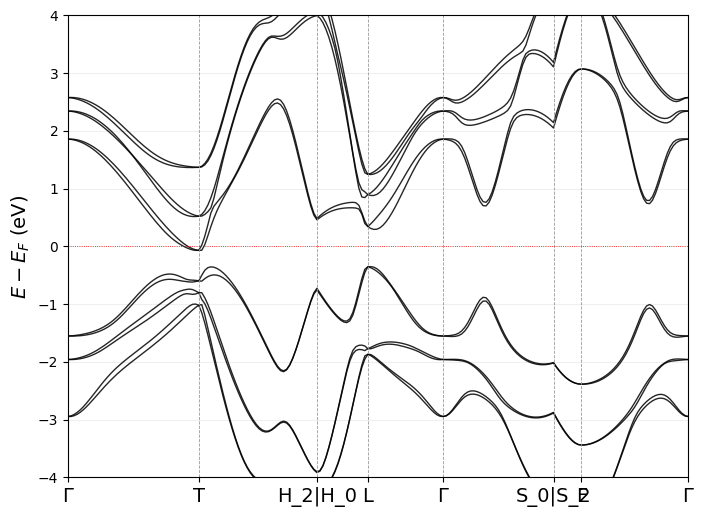

In [6]:
#Plot band structure using SeeKPath
fig = bulk_band_structure(model, auto=True, structure=structure,
                          spacing=0.02, e_range=(-4, 4))
fig

Now let us convert to PyBinding format. This is useful for considering various geometries, disorder, vacancies, magnetic fields, and more. PyBinding also offers built in tools for computing DOS, LDOS, and can port to Kwant for scattering computations

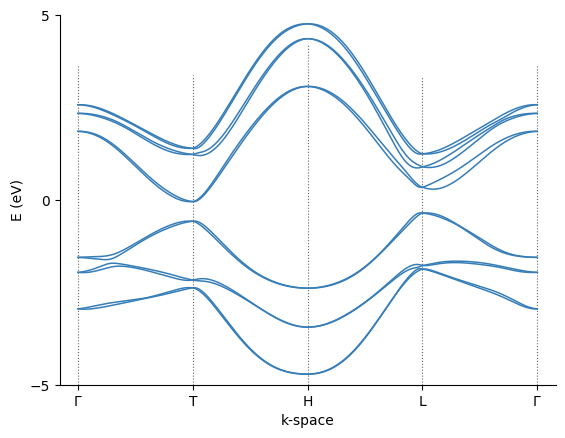

In [7]:
import matplotlib.pyplot as plt
import pybinding as pb
lat   = model.to_pb()

# `lat` is a pb.Lattice — use it like any other pybinding lattice:
import pybinding as pb
solver = pb.solver.lapack(pb.Model(lat, pb.translational_symmetry()))
rvec=lat.reciprocal_vectors()

Gamma=np.array([0,0,0])@rvec
H=np.array([-0.5,0,0.5])@rvec
T=np.array([0,0,0.5])@rvec
M=np.array([0.5,0.5,0])@rvec
L=np.array([-0.5,0,0])@rvec
bands = solver.calc_bands(Gamma, T, H, L, Gamma, step=0.01)
bands.plot(point_labels=[r'$\Gamma$', 'T', 'H', 'L', r'$\Gamma$'])
plt.ylim(-5,5)
plt.show()

Next lets open this model in PythTB, another common code for analyzing tight-binding models.


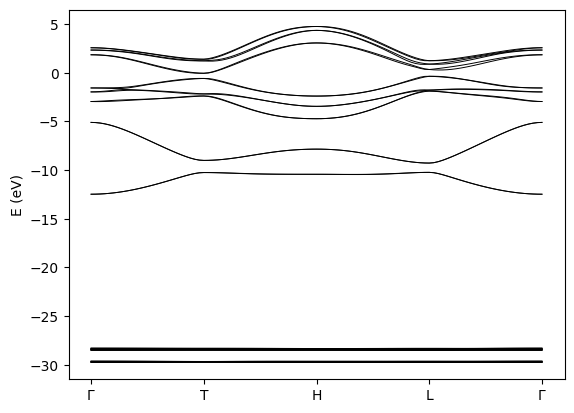

In [34]:
py_model = model.to_pythtb()

# PythTB does the path interpolation for you:
k_path, k_dist, k_node = py_model.k_path(
    [[0,0,0], [0,0,0.5],[-0.5,0,0.5], [-0.5,0,0], [0,0,0]],
    nk=101)
bands = py_model.solve_ham(k_path)                    # (num_wann, nk)

fig, ax = plt.subplots()
for band in np.transpose(bands):
  ax.plot(k_dist, band, lw=0.7, color="k")
ax.set_xticks(k_node, [r"$\Gamma$", "T", "H", "L", r"$\Gamma$"])
ax.set_ylabel("E (eV)")
plt.show()

Kwant currently has issues with installation on Google Colab. A separate tutorial is provided for loading a model iin Kwant and performing scattering computations